<!--
Software Name : learning-parities-with-product-networks
SPDX-FileCopyrightText: Copyright (c) 2026 Orange S.A.
SPDX-License-Identifier: MIT

This software is distributed under the MIT License .,
see the "LICENSE.md" file for more details or https://opensource.org/licenses/MIT

Author: Guillaume Larue, guillaume.larue@orange.com
Software description: Source code of the paper "Learning High-Dimensional Parity Functions with Product Networks"
-->

# Study B — Optimal Dataset Sparsity $p_e^*$ vs Problem Size $N$

Identifies the value of $p_e$ minimising the number of steps to convergence for each problem size $N$. Validates the a consistent scaling relationship $p_e^* \propto 1/N$. For each value of $N \in [10,1000]$, sweeps $p_e$ over [1/(2N), 10/N] and records the optimal $p_e$ that minimises steps to convergence.


**Data generated by:** [run_study_B.py](../studies/run_study_B.py)  
**Paper section:** Section 5.2.2 — Impact of Dataset Sparsity $p_e$ (Figure 4)

| Parameter | Value |
|-----------|-------|
| Problem Size $N$          | [10, 1000]         (50 values, log spaced)  |
| Num. Parallel Nodes $P$   | $\lfloor 1000 / N \rfloor$ |
| Learning Rate $\alpha$    | 0.1           |
| Batch Size $M$            | 100           |
| Bernouilli Prob. $p_e$    | [1/(2N), 10/N]     (50 values per N, linearly spaced)  |
| Max. Steps $S$            | 25000         | 
| Oracle Proportion $p_w$   | 0.5           |




In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import glob

# Add parent directory to path
sys.path.append('..')

from plotting.plot_utility import plot_metric_vs_param, compute_steps_to_thresholds, setup_plot_style

%matplotlib inline
setup_plot_style()

In [2]:
def get_latest_study_folder(study_prefix):
    pattern = f'../studies/results/{study_prefix}_*/'
    folders = glob.glob(pattern)
    if folders:
        return max(folders)  # Latest by name (timestamp-based)
    return None

mode = 'auto'  # Change to 'manual' to specify your own path

if mode == 'auto':
    results_dir = get_latest_study_folder('B_p_e_optimal')
    if results_dir is None:
        raise FileNotFoundError("No Study B results found. Run run_study_B.py first.")
    print(f"Auto-detected folder: {results_dir}")
else:
    results_dir = '../studies/results/B_p_e_optimal_XXXXXX_XXXXXX/'
    print(f"Using manual path: {results_dir}")

n_values = np.load(results_dir + 'n_values.npy')
optimal_p_e_per_n = np.load(results_dir + 'optimal_p_e_per_n.npy')
optimal_steps_per_n = np.load(results_dir + 'optimal_steps_per_n.npy')

# Filter out any N values greater than 500 (N>500 convergence in more than 10000 steps): 
# Get ID of N values <= 500
id = len(n_values)  # Default to last index
for i in range(len(n_values)):
    if n_values[i] > 1001: #600
        id = i  
        break

n_values = n_values[:id]
optimal_p_e_per_n = optimal_p_e_per_n[:id]
optimal_steps_per_n = optimal_steps_per_n[:id]

print(f"\nN range: {n_values[0]} to {n_values[-1]}")
print(f"Number of N values: {len(n_values)}")
print(f"\nOptimal p_e for each N:")
for N, p_e, steps in zip(n_values, optimal_p_e_per_n, optimal_steps_per_n):
    print(f"  N={N:4d}: p_e={p_e:.6f} (1/N: {1/N:.6f}), steps={steps:4.0f}")

Auto-detected folder: ../studies/results/B_p_e_optimal_20260420_200010/

N range: 10 to 1000
Number of N values: 50

Optimal p_e for each N:
  N=  10: p_e=0.166327 (1/N: 0.100000), steps= 173
  N=  10: p_e=0.166327 (1/N: 0.100000), steps= 173
  N=  12: p_e=0.154762 (1/N: 0.083333), steps= 202
  N=  13: p_e=0.142857 (1/N: 0.076923), steps= 218
  N=  14: p_e=0.132653 (1/N: 0.071429), steps= 233
  N=  15: p_e=0.136735 (1/N: 0.066667), steps= 246
  N=  17: p_e=0.109244 (1/N: 0.058824), steps= 281
  N=  19: p_e=0.107948 (1/N: 0.052632), steps= 308
  N=  21: p_e=0.097668 (1/N: 0.047619), steps= 347
  N=  23: p_e=0.089175 (1/N: 0.043478), steps= 373
  N=  25: p_e=0.074286 (1/N: 0.040000), steps= 413
  N=  28: p_e=0.073251 (1/N: 0.035714), steps= 450
  N=  30: p_e=0.068367 (1/N: 0.033333), steps= 479
  N=  33: p_e=0.062152 (1/N: 0.030303), steps= 526
  N=  37: p_e=0.055433 (1/N: 0.027027), steps= 593
  N=  40: p_e=0.051276 (1/N: 0.025000), steps= 637
  N=  44: p_e=0.046614 (1/N: 0.022727), ste

In [3]:
# Compute lim p_e for each N 
lim_p_e_per_n = []
lim_improvement = 0.1 # 10% improvement starting at an average distance of 0.5 = 0.4 threshold
for N in n_values:
    print(f"Compute lim p_e for N={N}", end='\r')
    # Load individual N results
    p_e_values = np.load(f"{results_dir}/N_{N}_p_e_values.npy")
    # steps = np.load(f"{results_dir}/N_{N}_steps.npy")
    p_diff_matrix = np.load(f"{results_dir}/N_{N}_p_diff_matrix.npy")

    # Compute Limit p_e
    p_e_id_lim = -1
    for p_e_index in range(p_e_values.shape[0]):
        # Parse results at a certain p_e
        id_lim = -1
        for i in range(p_diff_matrix.shape[1]):
            x = p_diff_matrix[p_e_index, i]
            if np.isnan(x):
                id_lim = i
                break
        #print(id_lim, p_diff_matrix[p_e_index, id_lim],p_diff_matrix[p_e_index, id_lim-1])
        if p_diff_matrix[p_e_index, id_lim-1] > 0.5*(1 - lim_improvement):
            p_e_id_lim = p_e_index
            break
    print(f"N={N}: Limit p_e ~ {p_e_values[p_e_id_lim]:.6f}")
    lim_p_e_per_n.append(p_e_values[p_e_id_lim])

N=10: Limit p_e ~ 0.670408
N=10: Limit p_e ~ 0.670408
N=12: Limit p_e ~ 0.623299
N=13: Limit p_e ~ 0.560440
N=14: Limit p_e ~ 0.534257
N=15: Limit p_e ~ 0.511565
N=17: Limit p_e ~ 0.462785
N=19: Limit p_e ~ 0.414071
N=21: Limit p_e ~ 0.383868
N=23: Limit p_e ~ 0.367347
N=25: Limit p_e ~ 0.337959
N=28: Limit p_e ~ 0.294825
N=30: Limit p_e ~ 0.275170
N=33: Limit p_e ~ 0.244280
N=37: Limit p_e ~ 0.238831
N=40: Limit p_e ~ 0.216071
N=44: Limit p_e ~ 0.192022
N=49: Limit p_e ~ 0.168471
N=54: Limit p_e ~ 0.160053
N=59: Limit p_e ~ 0.146489
N=65: Limit p_e ~ 0.127002
N=71: Limit p_e ~ 0.116269
N=79: Limit p_e ~ 0.102041
N=86: Limit p_e ~ 0.095990
N=95: Limit p_e ~ 0.086896
N=104: Limit p_e ~ 0.081240
N=115: Limit p_e ~ 0.070098
N=126: Limit p_e ~ 0.062439
N=138: Limit p_e ~ 0.058415
N=152: Limit p_e ~ 0.051759
N=167: Limit p_e ~ 0.045949
N=184: Limit p_e ~ 0.042757
N=202: Limit p_e ~ 0.037028
N=222: Limit p_e ~ 0.033692
N=244: Limit p_e ~ 0.030654
N=268: Limit p_e ~ 0.027909
N=294: Limit p_e 

## Optimal $p_e$ vs $N$

Empirically optimal $p_e^*$ (minimising convergence steps) plotted against $N$, with the theoretical value $p_e = 1/N$ as a reference. The limit $p_e^\text{lim}$ is the value above which convergence fail in the alloted number of steps. 

See Paper Section 5.2.2 Figure 4.


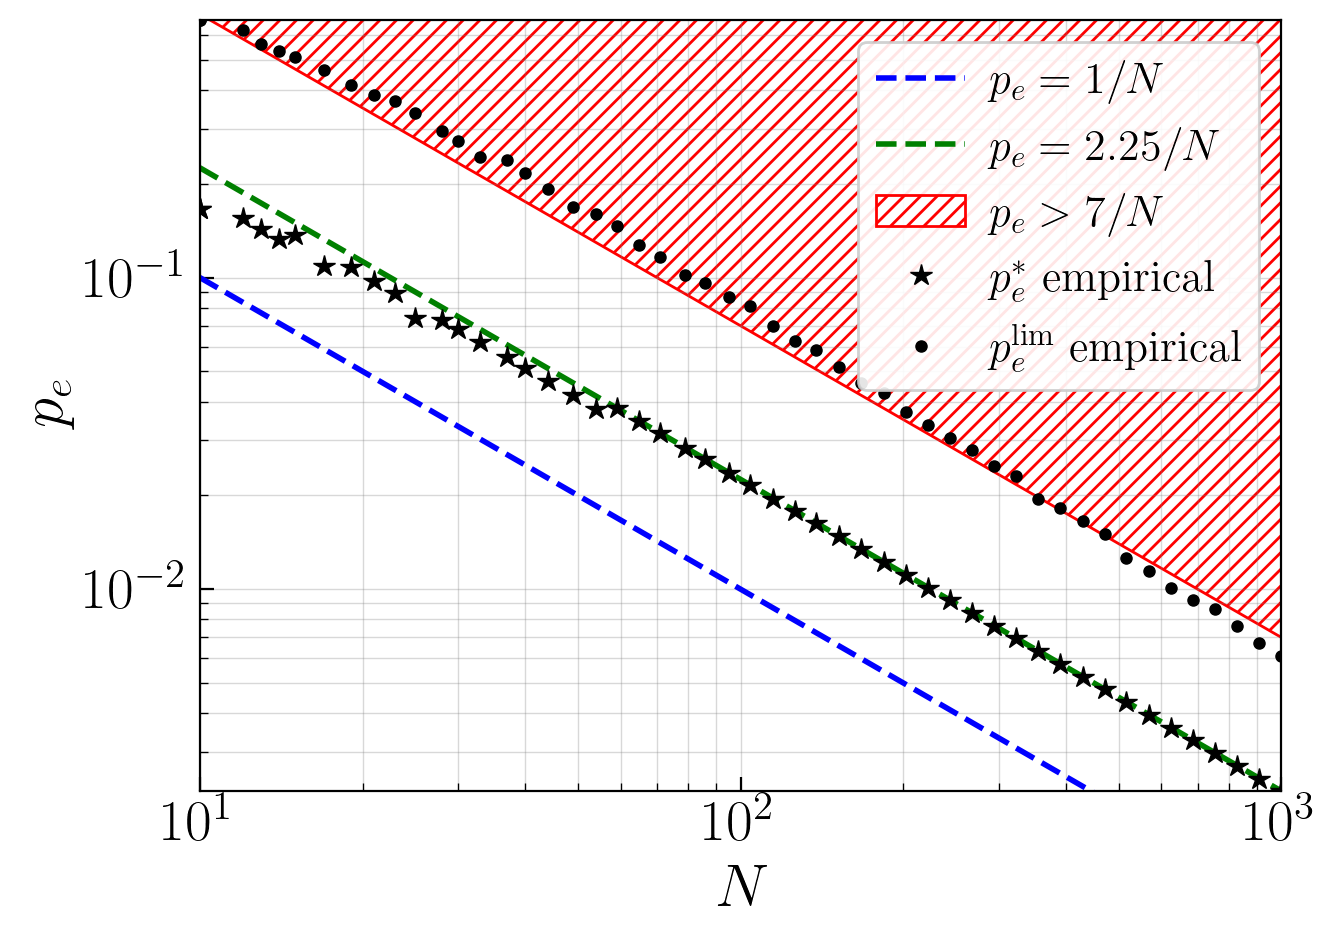

In [4]:
fig, ax = plt.subplots()

ax.plot(n_values, 1/n_values, 'b--', label='$p_e=1/N$', linewidth=2)
ax.plot(n_values, 2.25/n_values, 'g--', label='$p_e= 2.25/N$', linewidth=2)
ax.fill_between(n_values, 7/n_values, 0.7, hatch="////", facecolor="none", edgecolor="red", label='$p_e > 7/N$')

ax.plot(n_values, optimal_p_e_per_n, marker='*', color='black', markersize=8, label='$p_e^*$ empirical', linewidth=0)
ax.plot(n_values, lim_p_e_per_n, marker='.', color='black', markersize=8, label='$p_e^\\mathrm{lim}$ empirical', linewidth=0)

ax.set_xlabel('$N$')
ax.set_ylabel('$p_e$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim([n_values[0], n_values[-1]])
ax.set_ylim([min(optimal_p_e_per_n), max(lim_p_e_per_n)])
ax.legend()

plt.tight_layout()
plt.show()


## Additional Results - Steps to Convergence at $p_e^*$

Number of training steps required to converge when $p_e = p_e^*(N)$. A linear fit is overlaid to characterise the scaling law with $N$.


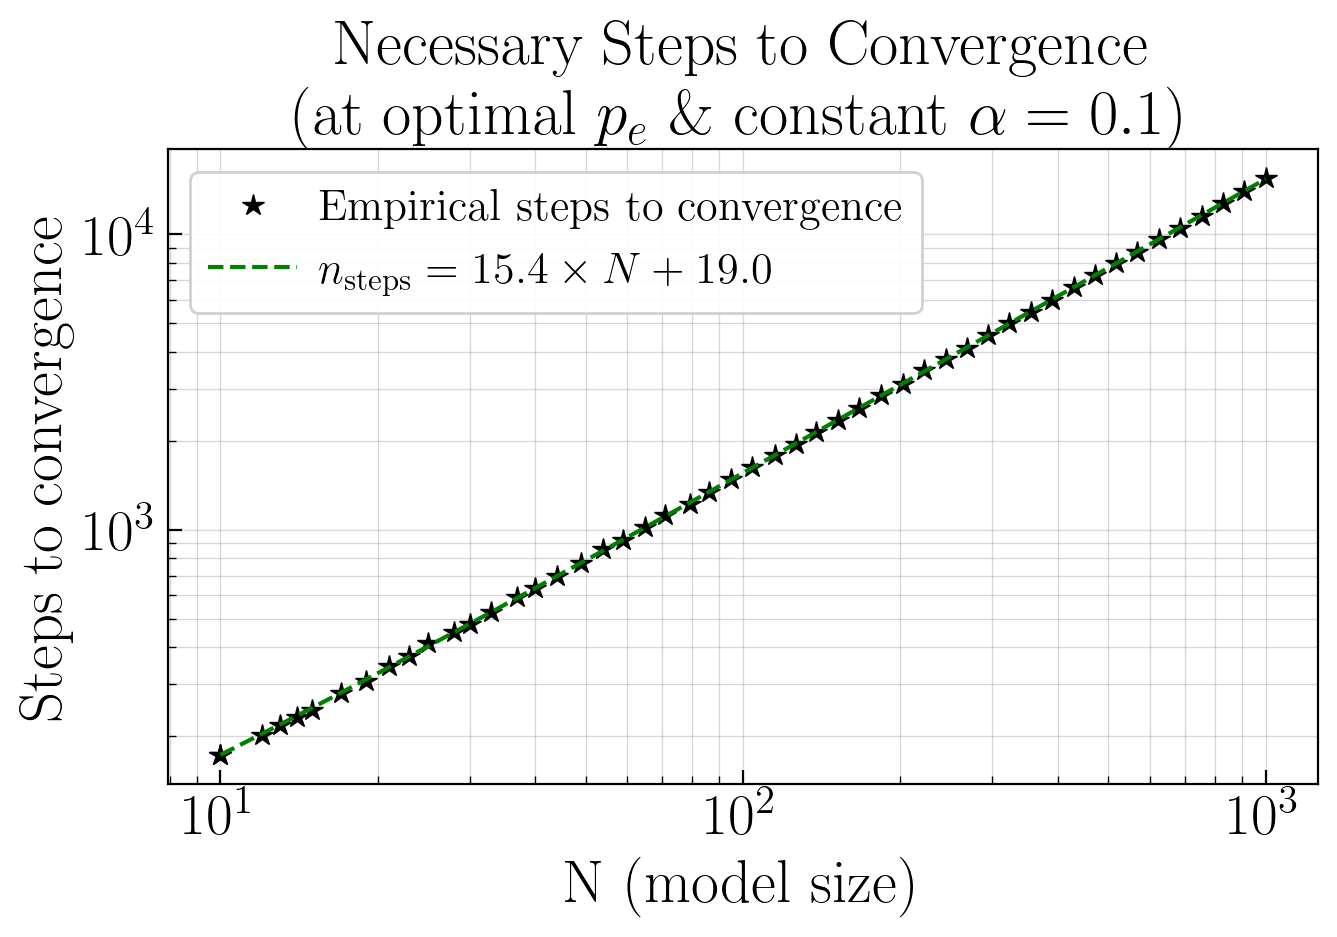

In [5]:
fig, ax = plt.subplots()

ax.plot(n_values, optimal_steps_per_n, color='black', marker='*', markersize=8, linewidth=0, label='Empirical steps to convergence')
# Exact a,b value to be refined
a = 15.4
b = 19
ax.plot(n_values, [a*n_values[i]+b for i in range(len(n_values))], color='green', linestyle='--', label=f'$n_\\mathrm{{steps}}={a:.1f} \\times N + {b:.1f}$')

ax.set_xlabel('N (model size)')
ax.set_ylabel('Steps to convergence')
ax.set_title('Necessary Steps to Convergence\n(at optimal $p_e$ \& constant $\\alpha=0.1$)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

## Additional Results - Convergence for Selected $N$ — Iso-Step Curves

Detailed view of the convergence landscape ($p_\text{diff}$ vs $p_e$ after a given number of steps) for a representative subset of $N$ values. Each subplot shows iso-step curves and highlights the empirically optimal $p_e^*$.


In [6]:
selected_n = n_values

def create_subplot_grid(rows, cols):
    """Create subplot grid using default figsize scaled by rows/cols."""
    default_width = plt.rcParams['figure.figsize'][0]
    default_height = plt.rcParams['figure.figsize'][1]
    figwidth = cols * default_width
    figheight = rows * default_height
    fig, axes = plt.subplots(rows, cols, figsize=(figwidth, figheight))
    return fig, axes

row, col = 12, 4
fig, axes = create_subplot_grid(row, col)

for idx, (ax, N) in enumerate(zip(axes.flatten(), selected_n)):
    print(f"Plot in progress n{idx} - N = {N}", end='\r')
    p_e_values = np.load(f"{results_dir}/N_{N}_p_e_values.npy")
    p_diff_matrix = np.load(f"{results_dir}/N_{N}_p_diff_matrix.npy")

    thresholds, steps_data = compute_steps_to_thresholds(p_e_values, p_diff_matrix, n_thresholds=9)

    plot_metric_vs_param(
        p_e_values,
        steps_data,
        ax,
        draw_best=False,
        xscale='log',
        yscale='linear',
        value_labels=thresholds,
        add_min_curve=False
    )

    optimal_p_e = np.load(f"{results_dir}/optimal_p_e_per_n.npy")
    global_idx = np.argwhere(n_values==selected_n[idx])[0][0]
    ax.axvline(x=optimal_p_e[global_idx], color='green', linestyle='--', label=f'$p_e^*$')
    ax.axvline(x=1/N, color='blue', linestyle='--', label=f'$p_e = 1/N$')
    ax.axvline(x=lim_p_e_per_n[global_idx], color='red', linestyle='--', label=f'$p_e^\\mathrm{{lim}}$')

    ax.set_xlabel('$p_e$')
    ax.set_ylabel('Steps to convergence')
    ax.set_title(f'N = {N}')
    ax.set_xscale('log')
    ax.legend()

plt.tight_layout()
plt.show()
